In [ ]:
# 1. Setup — only libraries that already ship with Colab
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
pd.set_option('display.max_colwidth', 40)
print("Environment ready ✅")

Environment ready ✅


In [ ]:
# 2. Sample backlog — edit freely
backlog = pd.DataFrame([
    {"initiative": "One-click checkout",          "business_value": 8, "time_criticality": 7, "risk_reduction": 4, "job_size": 3,
     "cost_usd": 40_000,  "benefit_usd": 260_000},
    {"initiative": "Mobile push notifications",    "business_value": 6, "time_criticality": 5, "risk_reduction": 3, "job_size": 2,
     "cost_usd": 25_000,  "benefit_usd": 90_000},
    {"initiative": "Multi-currency pricing",       "business_value": 7, "time_criticality": 8, "risk_reduction": 6, "job_size": 8,
     "cost_usd": 120_000, "benefit_usd": 300_000},
    {"initiative": "Referral program",             "business_value": 9, "time_criticality": 4, "risk_reduction": 5, "job_size": 5,
     "cost_usd": 60_000,  "benefit_usd": 340_000},
    {"initiative": "Legacy API migration",         "business_value": 3, "time_criticality": 9, "risk_reduction": 8, "job_size": 13,
     "cost_usd": 200_000, "benefit_usd": 150_000},
    {"initiative": "In-app support chat",          "business_value": 6, "time_criticality": 3, "risk_reduction": 2, "job_size": 5,
     "cost_usd": 55_000,  "benefit_usd": 110_000},
    {"initiative": "Personalized recommendations", "business_value": 8, "time_criticality": 5, "risk_reduction": 5, "job_size": 8,
     "cost_usd": 100_000, "benefit_usd": 280_000},
    {"initiative": "GDPR consent overhaul",        "business_value": 2, "time_criticality": 10,"risk_reduction": 9, "job_size": 5,
     "cost_usd": 70_000,  "benefit_usd": 80_000},
    {"initiative": "Dark mode",                    "business_value": 4, "time_criticality": 2, "risk_reduction": 1, "job_size": 2,
     "cost_usd": 15_000,  "benefit_usd": 40_000},
    {"initiative": "A/B testing platform",         "business_value": 5, "time_criticality": 4, "risk_reduction": 7, "job_size": 8,
     "cost_usd": 90_000,  "benefit_usd": 130_000},
])
backlog

,initiative,business_value,time_criticality,risk_reduction,job_size,cost_usd,benefit_usd
0,One-click checkout,8,7,4,3,40000,260000
1,Mobile push notifications,6,5,3,2,25000,90000
2,Multi-currency pricing,7,8,6,8,120000,300000
3,Referral program,9,4,5,5,60000,340000
4,Legacy API migration,3,9,8,13,200000,150000
5,In-app support chat,6,3,2,5,55000,110000
6,Personalized recommendations,8,5,5,8,100000,280000
7,GDPR consent overhaul,2,10,9,5,70000,80000
8,Dark mode,4,2,1,2,15000,40000
9,A/B testing platform,5,4,7,8,90000,130000


In [ ]:
# 3. Compute WSJF
backlog["cost_of_delay"] = (
    backlog["business_value"] + backlog["time_criticality"] + backlog["risk_reduction"]
)
backlog["wsjf"] = (backlog["cost_of_delay"] / backlog["job_size"]).round(2)

# 4. Compute a simple ROI (%) for comparison
backlog["roi_pct"] = (
    (backlog["benefit_usd"] - backlog["cost_usd"]) / backlog["cost_usd"] * 100
).round(0)

ranked_wsjf = backlog.sort_values("wsjf", ascending=False).reset_index(drop=True)
ranked_wsjf.index += 1
ranked_wsjf[["initiative", "cost_of_delay", "job_size", "wsjf", "roi_pct"]]

,initiative,cost_of_delay,job_size,wsjf,roi_pct
1,Mobile push notifications,14,2,7.00,260.0
2,One-click checkout,19,3,6.33,550.0
3,GDPR consent overhaul,21,5,4.20,14.0
4,Referral program,18,5,3.60,467.0
5,Dark mode,7,2,3.50,167.0
6,Multi-currency pricing,21,8,2.62,150.0
7,Personalized recommendations,18,8,2.25,180.0
8,In-app support chat,11,5,2.20,100.0
9,A/B testing platform,16,8,2.00,44.0
10,Legacy API migration,20,13,1.54,-25.0


### 5. Implement ICE (Impact, Confidence, Ease) Prioritization

In [13]:
backlog["reach"] = [
    100, 200, 50, 300, 10, 150, 250, 20, 80, 120
] # Example values (number of users/customers)
backlog["impact"] = [
    3, 2, 3, 4, 1, 2, 3, 1, 1, 2
] # Example values (1-5: Minimal, Low, Medium, High, Massive)
backlog["confidence"] = [
    0.8, 0.7, 0.9, 0.75, 0.6, 0.85, 0.7, 0.9, 0.5, 0.8
] # Example values (0.1-1.0: low to high)
backlog["effort"] = [
    5, 4, 8, 6, 10, 5, 7, 3, 2, 9
] # Example values (1-10: very small to very large effort/months)

# Calculate RICE score: (Reach * Impact * Confidence) / Effort
# To avoid division by zero for effort, we can add a small epsilon or handle it explicitly.
# Assuming effort will always be > 0 here based on example values.
backlog["rice_score"] = ((backlog["reach"] * backlog["impact"] * backlog["confidence"]) / backlog["effort"]).round(2)

ranked_rice = backlog.sort_values("rice_score", ascending=False).reset_index(drop=True)
ranked_rice.index += 1

display(ranked_rice[["initiative", "reach", "impact", "confidence", "effort", "rice_score"]])

,initiative,reach,impact,confidence,effort,rice_score
1,Referral program,300,4,0.75,6,150.00
2,Personalized recommendations,250,3,0.70,7,75.00
3,Mobile push notifications,200,2,0.70,4,70.00
4,In-app support chat,150,2,0.85,5,51.00
5,One-click checkout,100,3,0.80,5,48.00
6,A/B testing platform,120,2,0.80,9,21.33
7,Dark mode,80,1,0.50,2,20.00
8,Multi-currency pricing,50,3,0.90,8,16.88
9,GDPR consent overhaul,20,1,0.90,3,6.00
10,Legacy API migration,10,1,0.60,10,0.60


### 6. Compare WSJF, ROI, and RICE Rankings

,wsjf_rank,roi_rank,rice_rank
initiative,,,
Mobile push notifications,1,3,3
One-click checkout,2,1,5
GDPR consent overhaul,3,9,9
Referral program,4,2,1
Dark mode,5,5,7
Multi-currency pricing,6,6,8
Personalized recommendations,7,4,2
In-app support chat,8,7,4
A/B testing platform,9,8,6


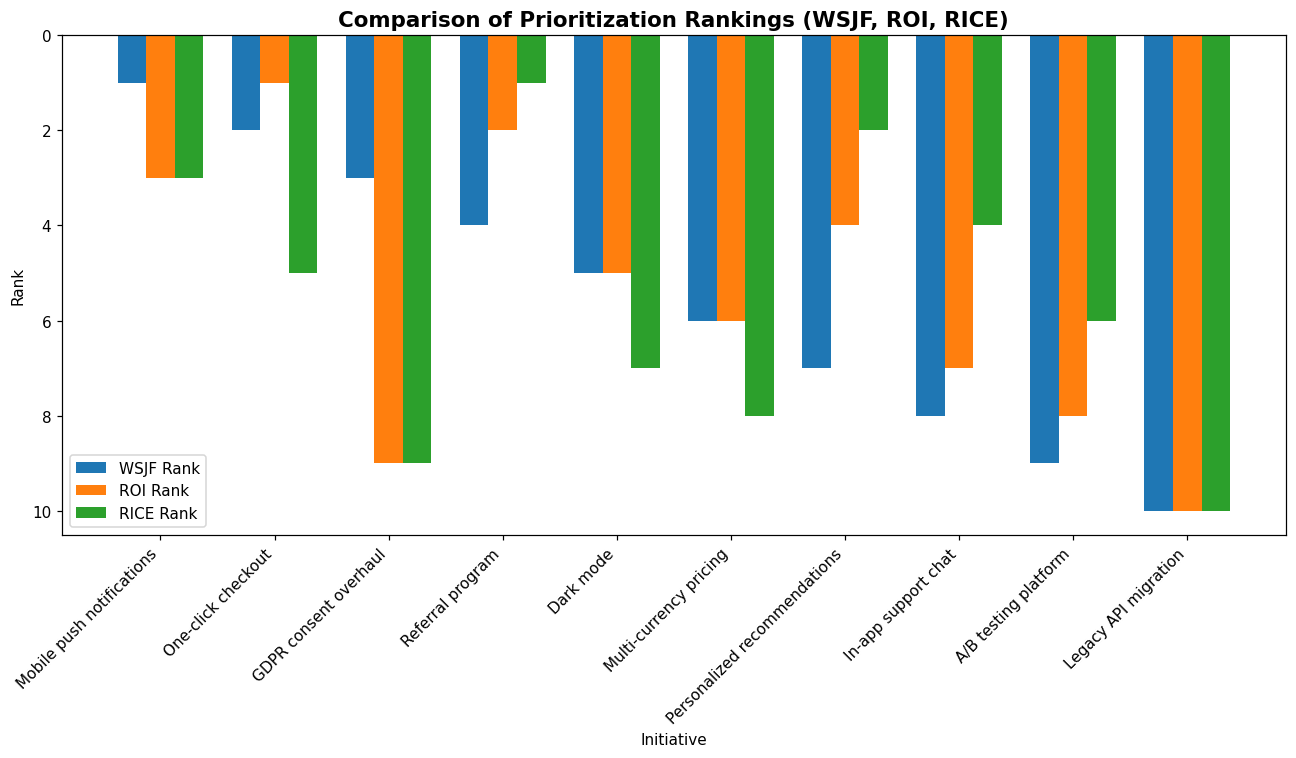

In [14]:
compare_all = backlog.copy()
compare_all["wsjf_rank"] = compare_all["wsjf"].rank(ascending=False).astype(int)
compare_all["roi_rank"] = compare_all["roi_pct"].rank(ascending=False).astype(int)
compare_all["rice_rank"] = compare_all["rice_score"].rank(ascending=False).astype(int)

compare_all = compare_all.sort_values("wsjf_rank")

display(compare_all[["initiative", "wsjf_rank", "roi_rank", "rice_rank"]].set_index("initiative"))

# Visualize the comparison of rankings
fig, ax = plt.subplots(figsize=(12, 7))

rank_columns = ["wsjf_rank", "roi_rank", "rice_rank"]
labels = ["WSJF Rank", "ROI Rank", "RICE Rank"]

x = np.arange(len(compare_all))
width = 0.25

for i, col in enumerate(rank_columns):
    ax.bar(x + i * width, compare_all[col], width, label=labels[i])

ax.set_xlabel("Initiative")
ax.set_ylabel("Rank")
ax.set_title("Comparison of Prioritization Rankings (WSJF, ROI, RICE)", fontsize=14, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(compare_all["initiative"], rotation=45, ha="right")
ax.legend()
ax.invert_yaxis() # Lower rank is better
plt.tight_layout()
plt.show()

### 7. Strategic Alignment: Incorporating a New Factor into Prioritization

In [15]:
backlog["strategic_alignment"] = [
    9, 6, 8, 7, 10, 5, 7, 9, 3, 6
] # Example values (1-10)

# Create a custom prioritization formula that includes strategic alignment
# For example, we can multiply WSJF by (strategic_alignment / 10) to scale it.
# Or add it as another component to the Cost of Delay.

# Option 1: Integrate into Cost of Delay (additive)
# Higher strategic alignment means higher overall value
backlog["wsjf_strategic"] = ((backlog["cost_of_delay"] + backlog["strategic_alignment"]) / backlog["job_size"]).round(2)

# Option 2: Multiply WSJF by strategic alignment (multiplicative)
# This would give more weight to strategic items
# backlog["wsjf_strategic"] = (backlog["wsjf"] * (backlog["strategic_alignment"] / 10)).round(2)

ranked_wsjf_strategic = backlog.sort_values("wsjf_strategic", ascending=False).reset_index(drop=True)
ranked_wsjf_strategic.index += 1

display(ranked_wsjf_strategic[["initiative", "strategic_alignment", "wsjf", "wsjf_strategic"]])

,initiative,strategic_alignment,wsjf,wsjf_strategic
1,Mobile push notifications,6,7.00,10.00
2,One-click checkout,9,6.33,9.33
3,GDPR consent overhaul,9,4.20,6.00
4,Referral program,7,3.60,5.00
5,Dark mode,3,3.50,5.00
6,Multi-currency pricing,8,2.62,3.62
7,In-app support chat,5,2.20,3.20
8,Personalized recommendations,7,2.25,3.12
9,A/B testing platform,6,2.00,2.75
10,Legacy API migration,10,1.54,2.31


### 8. Visualizing the Influence of Strategic Alignment

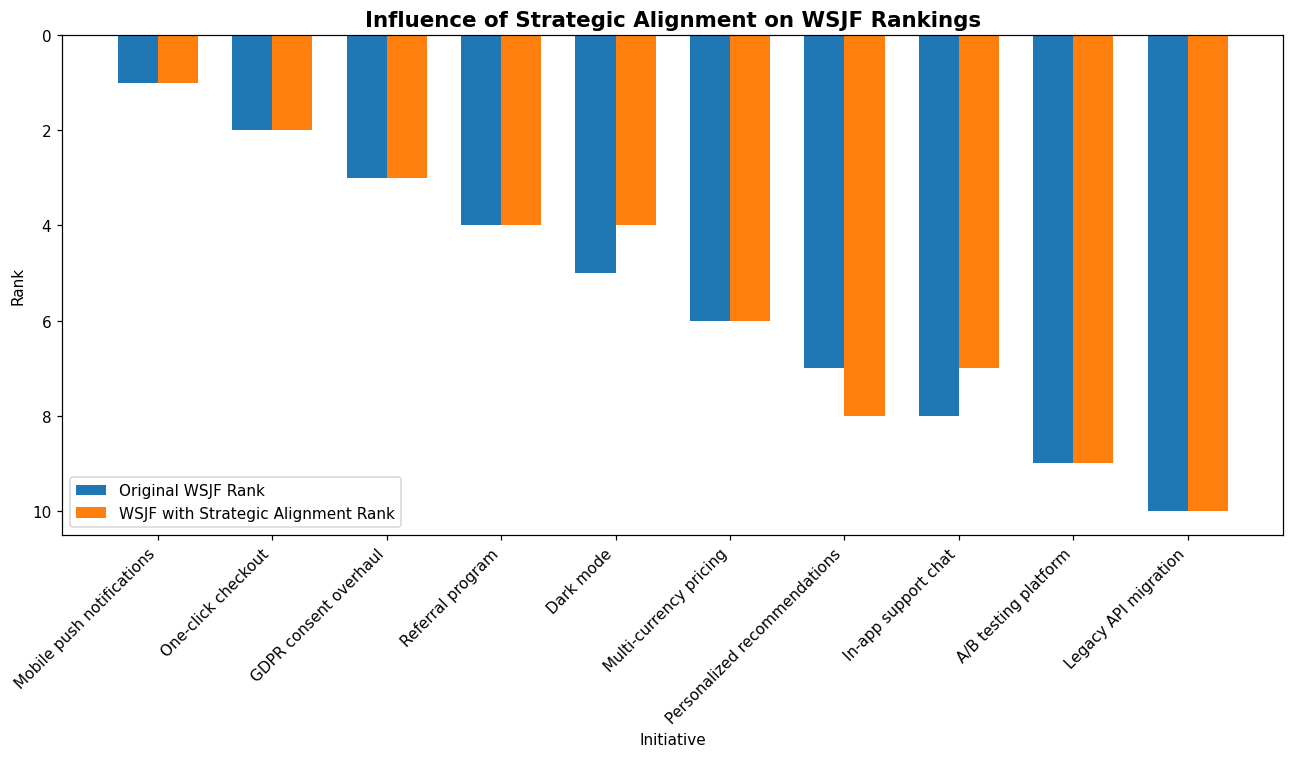

In [16]:
fig, ax = plt.subplots(figsize=(12, 7))

# Ranks before and after strategic alignment
compare_strategic = backlog.copy()
compare_strategic["wsjf_rank_original"] = compare_strategic["wsjf"].rank(ascending=False).astype(int)
compare_strategic["wsjf_rank_strategic"] = compare_strategic["wsjf_strategic"].rank(ascending=False).astype(int)

compare_strategic = compare_strategic.sort_values("wsjf_rank_original")

initiatives = compare_strategic["initiative"]
original_ranks = compare_strategic["wsjf_rank_original"]
strategic_ranks = compare_strategic["wsjf_rank_strategic"]

x = np.arange(len(initiatives))
width = 0.35

rects1 = ax.bar(x - width/2, original_ranks, width, label='Original WSJF Rank')
rects2 = ax.bar(x + width/2, strategic_ranks, width, label='WSJF with Strategic Alignment Rank')

ax.set_xlabel("Initiative")
ax.set_ylabel("Rank")
ax.set_title("Influence of Strategic Alignment on WSJF Rankings", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(initiatives, rotation=45, ha="right")
ax.legend()
ax.invert_yaxis() # Lower rank is better

# Add text labels for ranks
def autolabel(rects, ranks):
    for rect, rank in zip(rects, ranks):
        height = rect.get_height()
        ax.annotate(f'{rank}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# autolabel(rects1, original_ranks)
# autolabel(rects2, strategic_ranks)

plt.tight_layout()
plt.show()

### 9. Interactive WSJF Weight Adjustment

In [18]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Define weight sliders with initial values
bv_weight_slider = widgets.FloatSlider(
    value=1.0, min=0.1, max=5.0, step=0.1, description='Business Value Weight:',
    orientation='horizontal', readout=True, readout_format='.1f',
    style={'description_width': 'initial'}
)
tc_weight_slider = widgets.FloatSlider(
    value=1.0, min=0.1, max=5.0, step=0.1, description='Time Criticality Weight:',
    orientation='horizontal', readout=True, readout_format='.1f',
    style={'description_width': 'initial'}
)
rr_weight_slider = widgets.FloatSlider(
    value=1.0, min=0.1, max=5.0, step=0.1, description='Risk Reduction Weight:',
    orientation='horizontal', readout=True, readout_format='.1f',
    style={'description_width': 'initial'}
)
js_weight_slider = widgets.FloatSlider(
    value=1.0, min=0.1, max=5.0, step=0.1, description='Job Size Weight (Divisor):',
    orientation='horizontal', readout=True, readout_format='.1f',
    style={'description_width': 'initial'}
)

output_area = widgets.Output()

def update_wsjf_rankings(change):
    with output_area:
        clear_output(wait=True)
        temp_backlog = backlog.copy()

        # Apply new weights to the WSJF calculation
        temp_backlog['weighted_cost_of_delay'] = (
            temp_backlog['business_value'] * bv_weight_slider.value +
            temp_backlog['time_criticality'] * tc_weight_slider.value +
            temp_backlog['risk_reduction'] * rr_weight_slider.value
        )
        # Ensure job_size doesn't become zero or negative, if weights make it so
        # For weighted job_size, a higher weight means it contributes more to the denominator,
        # making the overall WSJF smaller. We'll use 1.0 as a floor for the weighted job_size.
        weighted_job_size = temp_backlog['job_size'] * js_weight_slider.value
        temp_backlog['weighted_wsjf'] = (temp_backlog['weighted_cost_of_delay'] / weighted_job_size).round(2)

        ranked_by_weights = temp_backlog.sort_values('weighted_wsjf', ascending=False).reset_index(drop=True)
        ranked_by_weights.index += 1

        print("Current WSJF Rankings with Custom Weights:")
        display(ranked_by_weights[[
            'initiative', 'business_value', 'time_criticality', 'risk_reduction', 'job_size',
            'weighted_cost_of_delay', 'weighted_wsjf'
        ]])

# Attach the update function to observe changes in sliders
bv_weight_slider.observe(update_wsjf_rankings, names='value')
tc_weight_slider.observe(update_wsjf_rankings, names='value')
rr_weight_slider.observe(update_wsjf_rankings, names='value')
js_weight_slider.observe(update_wsjf_rankings, names='value')

# Display widgets and initial rankings
display(widgets.VBox([
    bv_weight_slider,
    tc_weight_slider,
    rr_weight_slider,
    js_weight_slider,
    output_area
]))

# Trigger initial display
update_wsjf_rankings(None)

### 9. Interactive WSJF Weight Adjustment

In [17]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Define weight sliders with initial values
bv_weight_slider = widgets.FloatSlider(
    value=1.0, min=0.1, max=5.0, step=0.1, description='Business Value Weight:',
    orientation='horizontal', readout=True, readout_format='.1f',
    style={'description_width': 'initial'}
)
tc_weight_slider = widgets.FloatSlider(
    value=1.0, min=0.1, max=5.0, step=0.1, description='Time Criticality Weight:',
    orientation='horizontal', readout=True, readout_format='.1f',
    style={'description_width': 'initial'}
)
rr_weight_slider = widgets.FloatSlider(
    value=1.0, min=0.1, max=5.0, step=0.1, description='Risk Reduction Weight:',
    orientation='horizontal', readout=True, readout_format='.1f',
    style={'description_width': 'initial'}
)
js_weight_slider = widgets.FloatSlider(
    value=1.0, min=0.1, max=5.0, step=0.1, description='Job Size Weight (Divisor):',
    orientation='horizontal', readout=True, readout_format='.1f',
    style={'description_width': 'initial'}
)

output_area = widgets.Output()

def update_wsjf_rankings(change):
    with output_area:
        clear_output(wait=True)
        temp_backlog = backlog.copy()

        # Apply new weights to the WSJF calculation
        temp_backlog['weighted_cost_of_delay'] = (
            temp_backlog['business_value'] * bv_weight_slider.value +
            temp_backlog['time_criticality'] * tc_weight_slider.value +
            temp_backlog['risk_reduction'] * rr_weight_slider.value
        )
        # Ensure job_size doesn't become zero or negative, if weights make it so
        # For weighted job_size, a higher weight means it contributes more to the denominator,
        # making the overall WSJF smaller. We'll use 1.0 as a floor for the weighted job_size.
        weighted_job_size = temp_backlog['job_size'] * js_weight_slider.value
        temp_backlog['weighted_wsjf'] = (temp_backlog['weighted_cost_of_delay'] / weighted_job_size).round(2)

        ranked_by_weights = temp_backlog.sort_values('weighted_wsjf', ascending=False).reset_index(drop=True)
        ranked_by_weights.index += 1

        print("Current WSJF Rankings with Custom Weights:")
        display(ranked_by_weights[[
            'initiative', 'business_value', 'time_criticality', 'risk_reduction', 'job_size',
            'weighted_cost_of_delay', 'weighted_wsjf'
        ]])

# Attach the update function to observe changes in sliders
bv_weight_slider.observe(update_wsjf_rankings, names='value')
tc_weight_slider.observe(update_wsjf_rankings, names='value')
rr_weight_slider.observe(update_wsjf_rankings, names='value')
js_weight_slider.observe(update_wsjf_rankings, names='value')

# Display widgets and initial rankings
display(widgets.VBox([
    bv_weight_slider,
    tc_weight_slider,
    rr_weight_slider,
    js_weight_slider,
    output_area
]))

# Trigger initial display
update_wsjf_rankings(None)

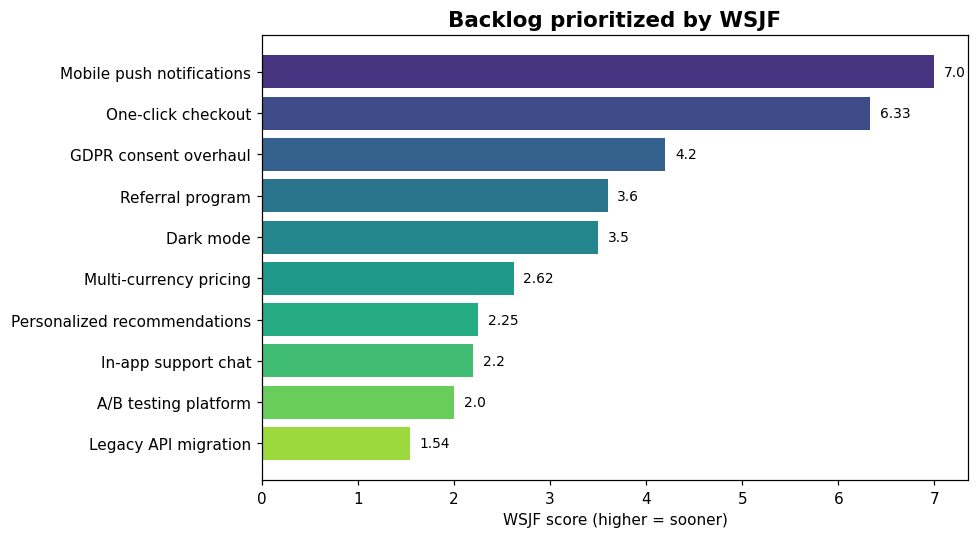

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(ranked_wsjf)))
bars = ax.barh(ranked_wsjf["initiative"], ranked_wsjf["wsjf"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("WSJF score (higher = sooner)")
ax.set_title("Backlog prioritized by WSJF", fontsize=14, fontweight="bold")
for bar, val in zip(bars, ranked_wsjf["wsjf"]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f"{val}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
compare = backlog.copy()
compare["wsjf_rank"] = compare["wsjf"].rank(ascending=False).astype(int)
compare["roi_rank"] = compare["roi_pct"].rank(ascending=False).astype(int)
compare["rank_delta"] = compare["roi_rank"] - compare["wsjf_rank"]
compare = compare.sort_values("wsjf_rank")

display(compare[["initiative", "wsjf_rank", "roi_rank", "rank_delta"]]
        .set_index("initiative"))

biggest_mover = compare.loc[compare["rank_delta"].abs().idxmax()]
print(f"\nBiggest disagreement: '{biggest_mover['initiative']}' "
      f"(WSJF rank {int(biggest_mover['wsjf_rank'])} vs ROI rank {int(biggest_mover['roi_rank'])}) — "
      f"WSJF's time-criticality / risk-reduction terms are pulling this one forward "
      f"even though its dollar ROI alone wouldn't justify the priority.")

,wsjf_rank,roi_rank,rank_delta
initiative,,,
Mobile push notifications,1,3,2
One-click checkout,2,1,-1
GDPR consent overhaul,3,9,6
Referral program,4,2,-2
Dark mode,5,5,0
Multi-currency pricing,6,6,0
Personalized recommendations,7,4,-3
In-app support chat,8,7,-1
A/B testing platform,9,8,-1



Biggest disagreement: 'GDPR consent overhaul' (WSJF rank 3 vs ROI rank 9) — WSJF's time-criticality / risk-reduction terms are pulling this one forward even though its dollar ROI alone wouldn't justify the priority.


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

item_dropdown = widgets.Dropdown(
    options=list(backlog["initiative"]), description="Initiative:",
    style={"description_width": "initial"}, layout=widgets.Layout(width="350px"))
bv_slider = widgets.IntSlider(value=5, min=1, max=10, description="Business value")
tc_slider = widgets.IntSlider(value=5, min=1, max=10, description="Time criticality")
rr_slider = widgets.IntSlider(value=5, min=1, max=10, description="Risk reduction")
js_slider = widgets.IntSlider(value=5, min=1, max=13, description="Job size")
out = widgets.Output()

def sync_sliders(change=None):
    row = backlog[backlog["initiative"] == item_dropdown.value].iloc[0]
    bv_slider.value, tc_slider.value = int(row.business_value), int(row.time_criticality)
    rr_slider.value, js_slider.value = int(row.risk_reduction), int(row.job_size)

def redraw(change=None):
    temp = backlog.copy()
    mask = temp["initiative"] == item_dropdown.value
    temp.loc[mask, "business_value"] = bv_slider.value
    temp.loc[mask, "time_criticality"] = tc_slider.value
    temp.loc[mask, "risk_reduction"] = rr_slider.value
    temp.loc[mask, "job_size"] = js_slider.value
    temp["wsjf"] = ((temp.business_value + temp.time_criticality + temp.risk_reduction)
                     / temp.job_size).round(2)
    temp = temp.sort_values("wsjf", ascending=False).reset_index(drop=True)
    temp.index += 1
    with out:
        clear_output(wait=True)
        display(temp[["initiative", "wsjf"]].style.apply(
            lambda s: ['background-color: #cadcfc' if v == item_dropdown.value else ''
                       for v in temp["initiative"]], axis=0, subset=["initiative"]))

item_dropdown.observe(lambda c: (sync_sliders(), redraw()), names="value")
for s in (bv_slider, tc_slider, rr_slider, js_slider):
    s.observe(redraw, names="value")

sync_sliders(); redraw()
display(widgets.VBox([item_dropdown, bv_slider, tc_slider, rr_slider, js_slider, out]))